In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py


In [2]:
filename = '/home/devlamin/WanKenoBEAM/StandardCases/TCV_88612_1.25_fluct/output/L4_QLabs_EDF_file0.hdf5'

data = {}
with h5py.File(filename, 'r') as f:
    for key in f.keys():
        print(key)
        if f[key].shape == ():
            data[key] = f[key][()]
        else:
            data[key] = f[key][:]
    



FreqGHz
Mode
TracesCorrectionFactor
TracesGroupVelocity
TracesMode
TracesNparallel
TracesNperpendicular
TracesNumberScattEvents
TracesNxNyNz
TracesPsi
TracesTheta
TracesTime
TracesWfct
TracesXYZ
TracesphiN
antennapolangle
antennatorangle
beamwidth1
beamwidth2
centraleta1
centraleta2
curvatureradius1
curvatureradius2
fileindex
inputfile
nmbrRays
rayStartX
rayStartY
rayStartZ


(1000, 5000)
(1000, 3, 5000)


Text(0, 0.5, 'Velocity norm')

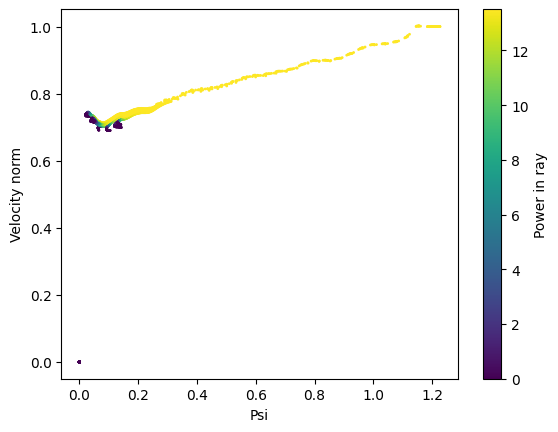

In [3]:
vel = data['TracesGroupVelocity']
psi = data['TracesPsi']
print(psi.shape)
print(vel.shape)
#Take the velocity norm 
vel_norm = np.linalg.norm(vel, axis=1)
power = data['TracesWfct']

# Plot the velocity norm against psi for the first 10 traces, coloured by power still in the ray
plt.figure()
plt.scatter(psi[:10], vel_norm[:10]/2, c=power[:10], cmap='viridis', s=1)
plt.colorbar(label='Power in ray')
plt.xlabel('Psi')
plt.ylabel('Velocity norm')